## 1 · Imports & Config

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.9 MB/s eta 0:00:00


In [3]:
import os, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Sklearn metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Gensim Word2Vec
from gensim.models import Word2Vec

print('TF version :', tf.__version__)
gpu = tf.config.list_physical_devices('GPU')
print('GPU available :', bool(gpu))


TF version : 2.20.0
GPU available : True


In [5]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT   = '/content/drive/MyDrive/SmartReviewAnalyzer'
FEATURES_DIR = os.path.join(DRIVE_ROOT, 'data/features')
PROCESSED_DIR= os.path.join(DRIVE_ROOT, 'data/processed')
MODELS_DIR   = os.path.join(DRIVE_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Hyper-parameters ──────────────────────────────────────────────
LSTM_MAXLEN      = 256     # pad/truncate sequences to this length
LSTM_EMBED_DIM   = 300     # must match W2V_VECTOR_SIZE in notebook 02
LSTM_UNITS       = 128     # BiLSTM hidden units (per direction)
LSTM_DROPOUT     = 0.3
LSTM_EPOCHS      = 10
LSTM_BATCH_SIZE  = 64

BERT_HIDDEN_UNITS= [256, 128]  # MLP layers on top of BERT embeddings
BERT_DROPOUT     = 0.3
BERT_EPOCHS      = 20
BERT_BATCH_SIZE  = 64

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('Config ready.')
print(f'  Features dir : {FEATURES_DIR}')
print(f'  Models dir   : {MODELS_DIR}')


Mounted at /content/drive
Config ready.
  Features dir : /content/drive/MyDrive/SmartReviewAnalyzer/data/features
  Models dir   : /content/drive/MyDrive/SmartReviewAnalyzer/models


## 2 · Load Features & Labels

In [7]:
# ── Labels ──
labels = np.load(os.path.join(FEATURES_DIR, 'labels.npz'))
y_train = labels['y_train']
y_test  = labels['y_test']
print(f'y_train : {y_train.shape}  classes={np.unique(y_train)}')
print(f'y_test  : {y_test.shape}')

# ── BERT embeddings (pre-computed in notebook 02) ──
X_train_bert = np.load(os.path.join(FEATURES_DIR, 'SmartReviewAnalyzer_features/X_train_bert.npy'))
X_test_bert  = np.load(os.path.join(FEATURES_DIR, 'SmartReviewAnalyzer_features/X_test_bert.npy'))
print(f'BERT train : {X_train_bert.shape}')
print(f'BERT test  : {X_test_bert.shape}')

# ── Word2Vec model & raw text (for sequence encoding) ──
w2v_model = Word2Vec.load(os.path.join(FEATURES_DIR, 'word2vec.model'))
print(f'W2V vocab  : {len(w2v_model.wv):,} words, dim={w2v_model.wv.vector_size}')

# ── Raw preprocessed text for LSTM token sequences ──
df_train = pd.read_csv(os.path.join(PROCESSED_DIR, 'preprocessed_train.csv'))
df_test  = pd.read_csv(os.path.join(PROCESSED_DIR, 'preprocessed_test.csv'))
train_texts = df_train['cleaned_text_tfidf'].fillna('').tolist()
test_texts  = df_test['cleaned_text_tfidf'].fillna('').tolist()
print(f'Raw train texts : {len(train_texts):,}')


y_train : (519575,)  classes=[0 1]
y_test  : (39972,)
BERT train : (519575, 384)
BERT test  : (39972, 384)
W2V vocab  : 89,744 words, dim=300
Raw train texts : 519,575


---
## 3 · LSTM + Word2Vec

Pipeline:
1. Build a **vocabulary index** from the W2V model
2. Convert each review to an **integer sequence**, pad to `LSTM_MAXLEN`
3. Initialise the **Embedding layer** with frozen W2V vectors
4. Stack a **Bidirectional LSTM** → Dropout → Dense(1, sigmoid)

### 3.1 · Build Vocabulary & Embedding Matrix

In [8]:
wv = w2v_model.wv
vocab = wv.index_to_key          # list of words ordered by frequency
word2idx = {w: i+1 for i, w in enumerate(vocab)}  # 0 reserved for padding
vocab_size = len(vocab) + 1

# Embedding matrix: row i → vector for word with index i
embedding_matrix = np.zeros((vocab_size, LSTM_EMBED_DIM), dtype=np.float32)
for word, idx in word2idx.items():
    embedding_matrix[idx] = wv[word]

print(f'Vocabulary size (incl. PAD) : {vocab_size:,}')
print(f'Embedding matrix shape      : {embedding_matrix.shape}')


Vocabulary size (incl. PAD) : 89,745
Embedding matrix shape      : (89745, 300)


### 3.2 · Tokenise & Pad Sequences

In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def texts_to_sequences(texts, word2idx, maxlen):
    seqs = [[word2idx[w] for w in t.split() if w in word2idx]
             for t in texts]
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

X_train_seq = texts_to_sequences(train_texts, word2idx, LSTM_MAXLEN)
X_test_seq  = texts_to_sequences(test_texts,  word2idx, LSTM_MAXLEN)

print(f'X_train_seq : {X_train_seq.shape}')
print(f'X_test_seq  : {X_test_seq.shape}')
print(f'Example     : {X_train_seq[0][:15]}')


X_train_seq : (519575, 256)
X_test_seq  : (39972, 256)
Example     : [  722 26371   170   107    27   933  8881    39   433   253   222  3437
    70     9    52]


### 3.3 · Build & Train Bi-LSTM Model

In [10]:
def build_lstm_model(vocab_size, embed_dim, embedding_matrix, maxlen,
                     lstm_units=128, dropout=0.3):
    inp = keras.Input(shape=(maxlen,), name='token_ids')
    x   = layers.Embedding(
              input_dim    = vocab_size,
              output_dim   = embed_dim,
              weights      = [embedding_matrix],
              input_length = maxlen,
              trainable    = False,   # keep W2V vectors frozen
              name         = 'w2v_embedding'
          )(inp)
    x   = layers.Bidirectional(
              layers.LSTM(lstm_units, return_sequences=True), name='bilstm_1'
          )(x)
    x   = layers.Bidirectional(
              layers.LSTM(lstm_units // 2), name='bilstm_2'
          )(x)
    x   = layers.Dropout(dropout)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = keras.Model(inp, out)
    return model

lstm_model = build_lstm_model(
    vocab_size, LSTM_EMBED_DIM, embedding_matrix, LSTM_MAXLEN,
    lstm_units=LSTM_UNITS, dropout=LSTM_DROPOUT
)
lstm_model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)
lstm_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ w2v_embedding (Embedding)       │ (None, 256, 300)       │    26,923,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 256, 256)       │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,535,469 (105.04 MB)

 Trainable params: 611,969 (2.33 MB)

 Non-trainable params: 26,923,500 (102.71 MB)

In [11]:
lstm_ckpt_path = os.path.join(MODELS_DIR, 'lstm_w2v_best.h5')

lstm_callbacks = [
    callbacks.ModelCheckpoint(
        lstm_ckpt_path, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    ),
]

print('Training LSTM + Word2Vec ...')
lstm_history = lstm_model.fit(
    X_train_seq, y_train,
    validation_split = 0.1,
    epochs           = LSTM_EPOCHS,
    batch_size       = LSTM_BATCH_SIZE,
    callbacks        = lstm_callbacks,
    verbose          = 1,
)


Training LSTM + Word2Vec ...
Epoch 1/10
7306/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9051 - loss: 0.2395
Epoch 1: val_accuracy improved from None to 0.95695, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/lstm_w2v_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/lstm_w2v_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 433s 58ms/step - accuracy: 0.9261 - loss: 0.1895 - val_accuracy: 0.9569 - val_loss: 0.1107 - learning_rate: 0.0010
Epoch 2/10
7306/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9460 - loss: 0.1397
Epoch 2: val_accuracy improved from 0.95695 to 0.96287, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/lstm_w2v_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/lstm_w2v_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 427s 58ms/step - accuracy: 0.9472 - loss: 0.1376 - val_accuracy: 0.9629 - val_loss: 0.0992 - learning_rate: 0.0010
Epoch 3/10
7306/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9537 - loss: 0.1213
Epoch 3: val_accuracy improved from 0.96287 to 0.96563, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/lstm_w2v_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/lstm_w2v_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 428s 59ms/step - accuracy: 0.9548 - loss: 0.1189 - val_accuracy: 0.9656 - val_loss: 0.0917 - learning_rate: 0.0010
Epoch 4/10
7306/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9605 - loss: 0.1044
Epoch 4: val_accuracy improved from 0.96563 to 0.96651, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/lstm_w2v_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/lstm_w2v_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 422s 58ms/step - accuracy: 0.9618 - loss: 0.1014 - val_accuracy: 0.9665 - val_loss: 0.0939 - learning_rate: 0.0010
Epoch 5/10
7306/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9670 - loss: 0.0885
Epoch 5: val_accuracy did not improve from 0.96651

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 421s 58ms/step - accuracy: 0.9686 - loss: 0.0849 - val_accuracy: 0.9645 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 6/10
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9748 - loss: 0.0688
Epoch 6: val_accuracy did not improve from 0.96651
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 444s 58ms/step - accuracy: 0.9771 - loss: 0.0628 - val_accuracy: 0.9636 - val_loss: 0.1201 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


### 3.4 · Evaluate LSTM

In [12]:
# Load best checkpoint weights
lstm_model.load_weights(lstm_ckpt_path)

lstm_proba  = lstm_model.predict(X_test_seq, batch_size=LSTM_BATCH_SIZE, verbose=0).ravel()
y_pred_lstm = (lstm_proba >= 0.5).astype(int)

np.save(os.path.join(MODELS_DIR, 'y_pred_lstm.npy'), y_pred_lstm)
np.save(os.path.join(MODELS_DIR, 'y_proba_lstm.npy'), lstm_proba)

lstm_metrics = dict(
    model     = 'LSTM + Word2Vec',
    accuracy  = accuracy_score(y_test, y_pred_lstm),
    precision = precision_score(y_test, y_pred_lstm, average='binary'),
    recall    = recall_score(y_test, y_pred_lstm, average='binary'),
    f1        = f1_score(y_test, y_pred_lstm, average='binary'),
)

print('\n── LSTM + Word2Vec ─────────────────────────────')
for k, v in lstm_metrics.items():
    if k != 'model': print(f'  {k:<12s}: {v:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lstm, target_names=['Negative','Positive']))



── LSTM + Word2Vec ─────────────────────────────
  accuracy    : 0.9547
  precision   : 0.9507
  recall      : 0.9591
  f1          : 0.9549

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.95     19981
    Positive       0.95      0.96      0.95     19991

    accuracy                           0.95     39972
   macro avg       0.95      0.95      0.95     39972
weighted avg       0.95      0.95      0.95     39972



---
## 4 · BERT Embedding Classifier

The pre-computed 384-d `all-MiniLM-L6-v2` embeddings are already L2-normalised.
We train a lightweight **MLP head** directly on top — no GPU needed for this step.

### 4.1 · Build & Train MLP on BERT Embeddings

In [13]:
def build_bert_mlp(input_dim, hidden_units, dropout):
    inp = keras.Input(shape=(input_dim,), name='bert_embedding')
    x   = inp
    for units in hidden_units:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    return keras.Model(inp, out)

bert_clf = build_bert_mlp(
    input_dim    = X_train_bert.shape[1],
    hidden_units = BERT_HIDDEN_UNITS,
    dropout      = BERT_DROPOUT
)
bert_clf.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)
bert_clf.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bert_embedding (InputLayer)     │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,121 (520.00 KB)

 Trainable params: 132,353 (517.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [14]:
bert_ckpt_path = os.path.join(MODELS_DIR, 'bert_mlp_best.h5')

bert_callbacks = [
    callbacks.ModelCheckpoint(
        bert_ckpt_path, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
]

print('Training BERT MLP classifier ...')
bert_history = bert_clf.fit(
    X_train_bert, y_train,
    validation_split = 0.1,
    epochs           = BERT_EPOCHS,
    batch_size       = BERT_BATCH_SIZE,
    callbacks        = bert_callbacks,
    verbose          = 1,
)


Training BERT MLP classifier ...
Epoch 1/20
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8690 - loss: 0.3082
Epoch 1: val_accuracy improved from None to 0.91127, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.8797 - loss: 0.2852 - val_accuracy: 0.9113 - val_loss: 0.2169 - learning_rate: 0.0010
Epoch 2/20
7297/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8888 - loss: 0.2652
Epoch 2: val_accuracy improved from 0.91127 to 0.91612, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.8901 - loss: 0.2627 - val_accuracy: 0.9161 - val_loss: 0.2074 - learning_rate: 0.0010
Epoch 3/20
7303/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8938 - loss: 0.2546
Epoch 3: val_accuracy improved from 0.91612 to 0.91745, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.8942 - loss: 0.2539 - val_accuracy: 0.9175 - val_loss: 0.2039 - learning_rate: 0.0010
Epoch 4/20
7298/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8971 - loss: 0.2479
Epoch 4: val_accuracy improved from 0.91745 to 0.91955, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.8975 - loss: 0.2473 - val_accuracy: 0.9196 - val_loss: 0.1997 - learning_rate: 0.0010
Epoch 5/20
7290/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8992 - loss: 0.2429
Epoch 5: val_accuracy did not improve from 0.91955
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.8995 - loss: 0.2423 - val_accuracy: 0.9191 - val_loss: 0.1995 - learning_rate: 0.0010
Epoch 6/20
7296/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9011 - loss: 0.2383
Epoch 6: val_accuracy improved from 0.91955 to 0.92020, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5



Epoch 6: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9013 - loss: 0.2382 - val_accuracy: 0.9202 - val_loss: 0.1968 - learning_rate: 0.0010
Epoch 7/20
7294/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9031 - loss: 0.2341
Epoch 7: val_accuracy improved from 0.92020 to 0.92042, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5



Epoch 7: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9032 - loss: 0.2340 - val_accuracy: 0.9204 - val_loss: 0.1968 - learning_rate: 0.0010
Epoch 8/20
7296/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9052 - loss: 0.2309
Epoch 8: val_accuracy did not improve from 0.92042
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9050 - loss: 0.2306 - val_accuracy: 0.9200 - val_loss: 0.1978 - learning_rate: 0.0010
Epoch 9/20
7287/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9057 - loss: 0.2277
Epoch 9: val_accuracy did not improve from 0.92042

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9059 - loss: 0.2277 - val_accuracy: 0.9201 - val_loss: 0.1971 - learning_rate: 0.0010
Epoch 10/20
7302/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9094 - loss: 0.2197
Epoch 10: val_accuracy


Epoch 10: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9107 - loss: 0.2174 - val_accuracy: 0.9211 - val_loss: 0.1969 - learning_rate: 5.0000e-04
Epoch 11/20
7301/7307 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9124 - loss: 0.2141
Epoch 11: val_accuracy improved from 0.92115 to 0.92182, saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5



Epoch 11: finished saving model to /content/drive/MyDrive/SmartReviewAnalyzer/models/bert_mlp_best.h5
7307/7307 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9126 - loss: 0.2131 - val_accuracy: 0.9218 - val_loss: 0.1971 - learning_rate: 5.0000e-04
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.


### 4.2 · Evaluate BERT Classifier

In [15]:
bert_clf.load_weights(bert_ckpt_path)

bert_proba  = bert_clf.predict(X_test_bert, batch_size=BERT_BATCH_SIZE, verbose=0).ravel()
y_pred_bert = (bert_proba >= 0.5).astype(int)

np.save(os.path.join(MODELS_DIR, 'y_pred_bert.npy'), y_pred_bert)
np.save(os.path.join(MODELS_DIR, 'y_proba_bert.npy'), bert_proba)

bert_metrics = dict(
    model     = 'BERT MLP Classifier',
    accuracy  = accuracy_score(y_test, y_pred_bert),
    precision = precision_score(y_test, y_pred_bert, average='binary'),
    recall    = recall_score(y_test, y_pred_bert, average='binary'),
    f1        = f1_score(y_test, y_pred_bert, average='binary'),
)

print('\n── BERT MLP Classifier ─────────────────────────')
for k, v in bert_metrics.items():
    if k != 'model': print(f'  {k:<12s}: {v:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_bert, target_names=['Negative','Positive']))



── BERT MLP Classifier ─────────────────────────
  accuracy    : 0.9053
  precision   : 0.9101
  recall      : 0.8995
  f1          : 0.9048

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.91      0.91     19981
    Positive       0.91      0.90      0.90     19991

    accuracy                           0.91     39972
   macro avg       0.91      0.91      0.91     39972
weighted avg       0.91      0.91      0.91     39972



---
## 5 · Model Comparison & Visualisations

### 5.1 · Metrics Summary Table

In [16]:
all_metrics = [lstm_metrics, bert_metrics]
df_metrics  = pd.DataFrame(all_metrics).set_index('model')
df_metrics  = df_metrics.round(4)

print('\n══ Final Metrics ══════════════════════════════════')
print(df_metrics.to_string())

metrics_path = os.path.join(MODELS_DIR, 'metrics_summary.csv')
df_metrics.to_csv(metrics_path)
print(f'\nSaved → {metrics_path}')



══ Final Metrics ══════════════════════════════════
                     accuracy  precision  recall      f1
model                                                   
LSTM + Word2Vec        0.9547     0.9507  0.9591  0.9549
BERT MLP Classifier    0.9053     0.9101  0.8995  0.9048

Saved → /content/drive/MyDrive/SmartReviewAnalyzer/models/metrics_summary.csv


### 5.2 · Bar Chart — All Metrics

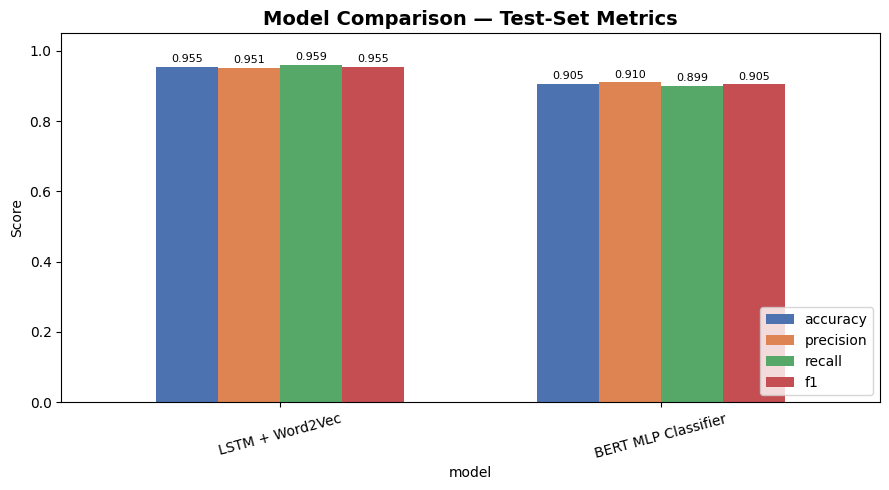

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
df_metrics[['accuracy','precision','recall','f1']].plot(
    kind='bar', ax=ax, rot=15, width=0.65,
    color=['#4C72B0','#DD8452','#55A868','#C44E52']
)
ax.set_title('Model Comparison — Test-Set Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'metrics_comparison.png'), dpi=150)
plt.show()


### 5.3 · Confusion Matrices

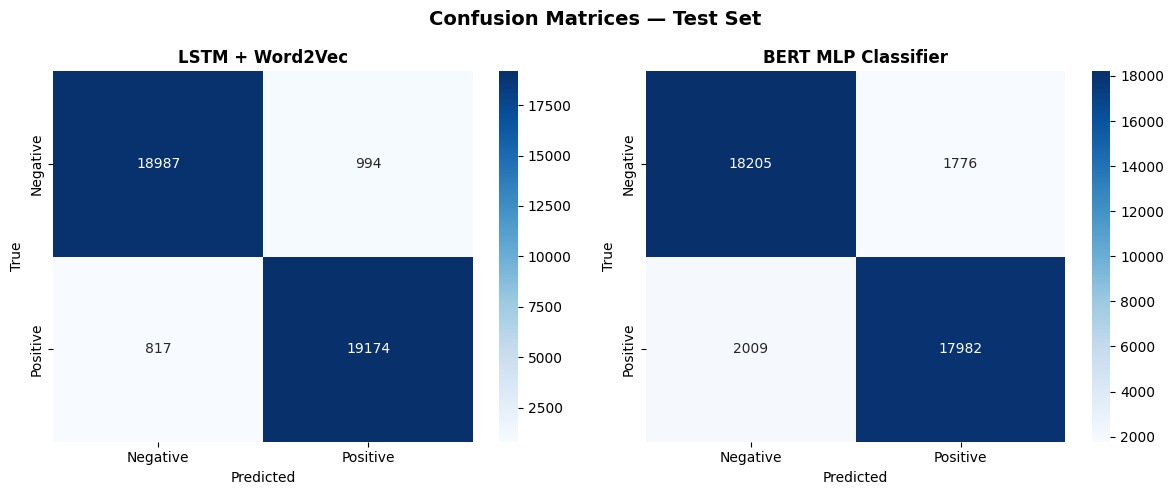

In [18]:
def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Negative','Positive'],
        yticklabels=['Negative','Positive']
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion(y_test, y_pred_lstm, 'LSTM + Word2Vec',       axes[0])
plot_confusion(y_test, y_pred_bert, 'BERT MLP Classifier',   axes[1])
plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()


### 5.4 · Training Curves

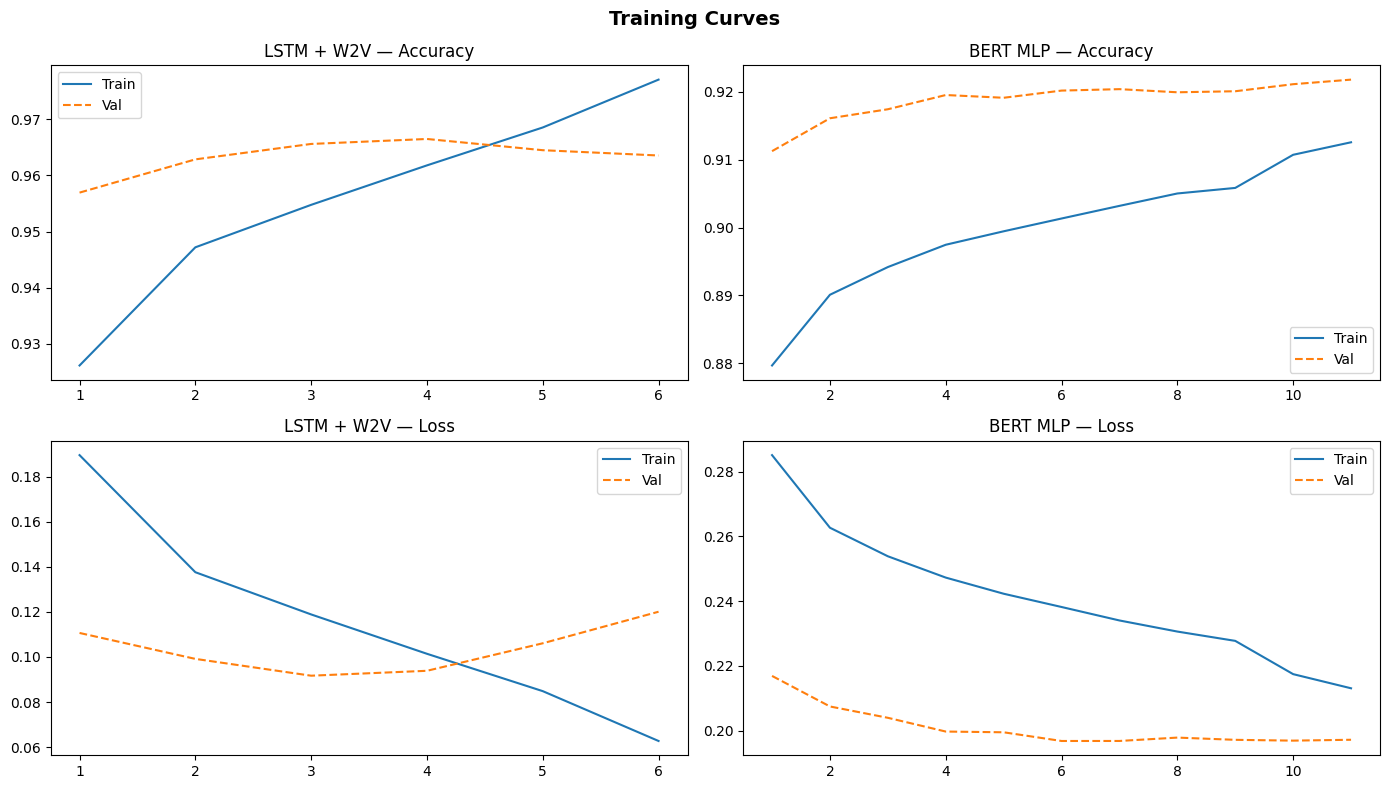

In [19]:
def plot_history(history, title, ax_acc, ax_loss):
    h = history.history
    epochs = range(1, len(h['accuracy'])+1)
    ax_acc.plot(epochs, h['accuracy'],     label='Train')
    ax_acc.plot(epochs, h['val_accuracy'], label='Val',  linestyle='--')
    ax_acc.set_title(f'{title} — Accuracy'); ax_acc.legend()
    ax_loss.plot(epochs, h['loss'],         label='Train')
    ax_loss.plot(epochs, h['val_loss'],     label='Val',  linestyle='--')
    ax_loss.set_title(f'{title} — Loss');   ax_loss.legend()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_history(lstm_history, 'LSTM + W2V',   axes[0][0], axes[1][0])
plot_history(bert_history, 'BERT MLP',     axes[0][1], axes[1][1])
plt.suptitle('Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'training_curves.png'), dpi=150)
plt.show()


## 6 · Predictions — Deliverable

In [20]:
# Combine all predictions into one DataFrame for easy inspection / downstream use
df_preds = pd.DataFrame({
    'y_true'          : y_test,
    'y_pred_lstm'     : y_pred_lstm,
    'y_proba_lstm'    : lstm_proba.round(4),
    'y_pred_bert'     : y_pred_bert,
    'y_proba_bert'    : bert_proba.round(4),
})

preds_path = os.path.join(MODELS_DIR, 'all_predictions.csv')
df_preds.to_csv(preds_path, index=False)

print('Predictions saved →', preds_path)
print(f'Shape : {df_preds.shape}')
df_preds.head(10)


Predictions saved → /content/drive/MyDrive/SmartReviewAnalyzer/models/all_predictions.csv
Shape : (39972, 5)


,y_true,y_pred_lstm,y_proba_lstm,y_pred_bert,y_proba_bert
0,0,0,0.0005,0,0.0000
1,0,0,0.0018,0,0.0249
2,0,0,0.0000,0,0.0023
3,0,0,0.0000,0,0.0002
4,0,0,0.0000,0,0.0008
5,0,0,0.1396,0,0.1101
6,1,1,0.9971,1,0.9959
7,1,1,0.9278,1,0.8472
8,0,0,0.0381,0,0.2738
9,1,1,0.9850,1,0.9880


## 7 · Deliverables Summary

In [21]:
print('═'*55)
print(' DELIVERABLES')
print('═'*55)
artefacts = [
    ('Trained model (LSTM)',        'lstm_w2v_best.h5'),
    ('Trained model (BERT MLP)',    'bert_mlp_best.h5'),
    ('Metrics summary',             'metrics_summary.csv'),
    ('All predictions',             'all_predictions.csv'),
    ('Metric bar chart',            'metrics_comparison.png'),
    ('Confusion matrices',          'confusion_matrices.png'),
    ('Training curves',             'training_curves.png'),
    ('LSTM predictions (npy)',      'y_pred_lstm.npy'),
    ('BERT predictions (npy)',      'y_pred_bert.npy'),
]
for label, fname in artefacts:
    fpath = os.path.join(MODELS_DIR, fname)
    exists = os.path.exists(fpath)
    size   = f'{os.path.getsize(fpath)/1e6:.2f} MB' if exists else 'not found'
    status = '✓' if exists else '✗'
    print(f'  {status}  {label:<35s}  {fname:<35s}  {size}')
print('═'*55)
print('\nFinal Metrics:')
print(df_metrics.to_string())


═══════════════════════════════════════════════════════
 DELIVERABLES
═══════════════════════════════════════════════════════
  ✓  Trained model (LSTM)                 lstm_w2v_best.h5                     115.11 MB
  ✓  Trained model (BERT MLP)             bert_mlp_best.h5                     1.64 MB
  ✓  Metrics summary                      metrics_summary.csv                  0.00 MB
  ✓  All predictions                      all_predictions.csv                  0.76 MB
  ✓  Metric bar chart                     metrics_comparison.png               0.05 MB
  ✓  Confusion matrices                   confusion_matrices.png               0.08 MB
  ✓  Training curves                      training_curves.png                  0.16 MB
  ✓  LSTM predictions (npy)               y_pred_lstm.npy                      0.32 MB
  ✓  BERT predictions (npy)               y_pred_bert.npy                      0.32 MB
═══════════════════════════════════════════════════════

Final Metrics:
                 